# 09_prott5_finetune

In [ ]:
# 导入库
import copy
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

In [32]:
# 路径定义与数据读取
PROJECT_ROOT = Path.cwd().parent.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
INTERIM_DIR = DATA_DIR / "interim"

RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = RESULTS_DIR / "models"
LOGS_DIR = RESULTS_DIR / "logs"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

In [33]:
train_df = pd.read_csv(PROCESSED_DIR / "prott5_residue" / "train_metadata.csv")
test_df = pd.read_csv(PROCESSED_DIR / "prott5_residue" / "test_metadata.csv")

print(train_df.shape)
print(test_df.shape)
train_df.head()

(3583, 2)
(897, 2)


,sequence,label
0,SLLLNGGCKVSNYDE,1
1,DAEFRHDSGYEVHHQ,1
2,GRTGRGKPGIYRFVAPGE,1
3,ASLKPEFVQIINAKN,1
4,KCEFQDAYVLLSEKK,1


In [34]:
# 从训练集里再划一个 validation set
train_sub_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)

train_sub_df = train_sub_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("train_sub:", train_sub_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train_sub: (2866, 2)
val: (717, 2)
test: (897, 2)


In [35]:
# 导入，tokenizer
import os
from transformers import T5Tokenizer, T5EncoderModel

MODEL_NAME = "Rostlab/prot_t5_base_mt_uniref50"

tokenizer = T5Tokenizer.from_pretrained(
    MODEL_NAME,
    do_lower_case=False
)

In [36]:
# Dataset序列处理
class ProtT5Dataset(Dataset):
    def __init__(self, df):
        self.sequences = df["sequence"].tolist()
        self.labels = df["label"].astype(float).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        seq = self.sequences[idx]

        # ⭐ 核心：加空格
        seq = " ".join(list(seq))

        return {
            "sequence": seq,
            "label": self.labels[idx]
        }

In [37]:
# collate fn
def collate_fn(batch):
    sequences = [item["sequence"] for item in batch]
    labels = torch.tensor([item["label"] for item in batch], dtype=torch.float32).unsqueeze(1)

    encoded = tokenizer(
        sequences,
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )

    return {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "label": labels
    }

In [38]:
# 构建Dataloader
train_dataset = ProtT5Dataset(train_sub_df)
val_dataset = ProtT5Dataset(val_df)
test_dataset = ProtT5Dataset(test_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)



In [39]:
# 模型定义
class ProtT5Classifier(nn.Module):
    def __init__(self, backbone, hidden_dim, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 1)

    def masked_mean_pooling(self, hidden_states, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        hidden_states = hidden_states * mask
        summed = hidden_states.sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-6)
        return summed / counts

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state

        pooled = self.masked_mean_pooling(hidden, attention_mask)
        pooled = self.dropout(pooled)

        logits = self.classifier(pooled)
        return logits

In [40]:
device = "cuda" if torch.cuda.is_available() else "cpu"

backbone = T5EncoderModel.from_pretrained(MODEL_NAME)
hidden_dim = backbone.config.d_model

model = ProtT5Classifier(backbone, hidden_dim, dropout=0.3).to(device)

# ❗先冻结
for param in model.backbone.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/112 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
T5EncoderModel LOAD REPORT from: Rostlab/prot_t5_base_mt_uniref50
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [41]:
# optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW([
    {"params": model.classifier.parameters(), "lr": 1e-3},
    {"params": model.backbone.encoder.block[-2:].parameters(), "lr": 1e-5}
])

In [42]:
# 定义 train / evaluate 函数
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

    return running_loss / len(loader.dataset) 

In [43]:
# 定义指标函数
def compute_metrics(y_true, y_pred, y_prob):
    return {
        "ACC": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

In [44]:
def evaluate_on_loader(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)

            running_loss += loss.item() * labels.size(0)

            all_labels.extend(labels.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    avg_loss = running_loss / len(loader.dataset)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return avg_loss, metrics, all_labels, all_preds, all_probs

In [48]:
# train，evaluate
# 循环训练
num_epochs = 100
best_val_auc = -1
best_model_state = None

patience = 24
counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_metrics, _, _, _ = evaluate_on_loader(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_metrics["ROC_AUC"])

    print(f"Epoch {epoch:02d}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val AUC:    {val_metrics['ROC_AUC']:.4f}")
    print(f"  Val F1:     {val_metrics['F1']:.4f}")
    print(f"  Val MCC:    {val_metrics['MCC']:.4f}")

    if val_metrics["ROC_AUC"] > best_val_auc:
        best_val_auc = val_metrics["ROC_AUC"]
        best_model_state = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

Epoch 01
  Train Loss: 0.6428
  Val Loss:   0.6341
  Val AUC:    0.6317
  Val F1:     0.4028
  Val MCC:    0.1914
Epoch 02
  Train Loss: 0.6404
  Val Loss:   0.6324
  Val AUC:    0.6321
  Val F1:     0.4276
  Val MCC:    0.2151
Epoch 03
  Train Loss: 0.6368
  Val Loss:   0.6320
  Val AUC:    0.6321
  Val F1:     0.4276
  Val MCC:    0.2151
Epoch 04
  Train Loss: 0.6381
  Val Loss:   0.6343
  Val AUC:    0.6317
  Val F1:     0.4028
  Val MCC:    0.1914
Epoch 05
  Train Loss: 0.6413
  Val Loss:   0.6317
  Val AUC:    0.6321
  Val F1:     0.4276
  Val MCC:    0.2151
Epoch 06
  Train Loss: 0.6383
  Val Loss:   0.6304
  Val AUC:    0.6321
  Val F1:     0.4276
  Val MCC:    0.2151
Epoch 07
  Train Loss: 0.6356
  Val Loss:   0.6300
  Val AUC:    0.6321
  Val F1:     0.4276
  Val MCC:    0.2151
Epoch 08
  Train Loss: 0.6371
  Val Loss:   0.6300
  Val AUC:    0.6321
  Val F1:     0.4276
  Val MCC:    0.2151
Epoch 09
  Train Loss: 0.6360
  Val Loss:   0.6307
  Val AUC:    0.6321
  Val F1:     0.

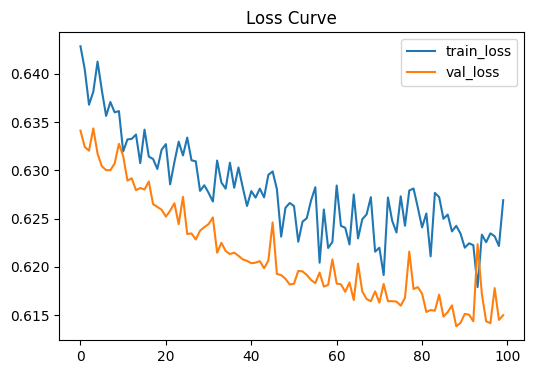

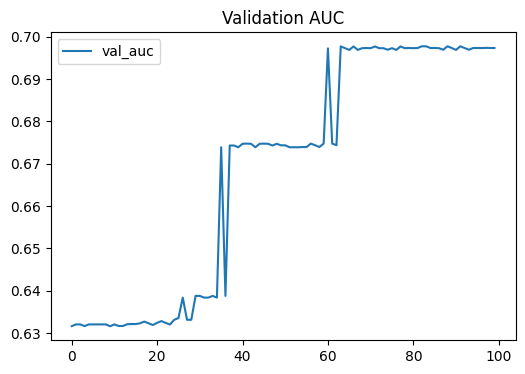

In [49]:
# 画训练曲线
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history["val_auc"], label="val_auc")
plt.legend()
plt.title("Validation AUC")
plt.show()

In [50]:
# 加载最佳模型，在测试集上评估
model.load_state_dict(best_model_state)

test_loss, test_metrics, y_true_test, y_pred_test, y_prob_test = evaluate_on_loader(
    model, test_loader, criterion, device
)

print("Test Loss:", round(test_loss, 4))
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Test Loss: 0.6152
ACC: 0.6644
Precision: 0.5903
Recall: 0.3918
F1: 0.4710
MCC: 0.2505
ROC_AUC: 0.6748
PR_AUC: 0.5238
